# ARQ KYC Funnel Analysis

**Period covered:** July 25 – September 22, 2023  
**Datasets:** `KYC_Summary` · `KYC_Details`  
**Goal:** Figure out why our KYC pass rate has been dropping and what we can do about it.

---

The KYC process has four checks run by Jumio (our external partner):
1. **ID verification** – is the document real and readable?
2. **Liveness verification** – is the selfie a live person, not a photo?
3. **Identity verification** – does the selfie match the ID photo?
4. **Watchlist screening** – is the person flagged on any sanctions list?

This notebook walks through each failure point to find the biggest levers.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# I like to keep colours in one place so I can tweak the palette without
# hunting through every chart.
NAVY  = '#1E3A5F'
TEAL  = '#0D9488'
CORAL = '#EF4444'
AMBER = '#F59E0B'
GREY  = '#94A3B8'
BG    = '#F8FAFC'

# Apply a clean, minimal style to all matplotlib charts.
plt.rcParams.update({
    'font.family'        : 'sans-serif',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.facecolor'     : BG,
    'figure.facecolor'   : 'white',
})

## 2. Load the Data

We have two files:
- **KYC_Summary** – one row per KYC attempt with a final decision and date.
- **KYC_Details** – granular per-check outcomes (usability, liveness, similarity, etc.).

Not every summary record has a matching details row (only ~10% overlap on `user_reference`),
so I treat them separately and join only when I need the check-level breakdown.

In [2]:
# Load both files — update these paths if you move the CSVs.
details = pd.read_csv('KYC_details (1).csv')
summary = pd.read_csv('KYC_summary (3).csv')

# Parse the date column so we can do time-based grouping later.
summary['date_'] = pd.to_datetime(summary['date_'])

print(f'Summary : {summary.shape[0]:,} rows, {summary.shape[1]} columns')
print(f'Details : {details.shape[0]:,} rows, {details.shape[1]} columns')

Summary : 52,075 rows, 3 columns
Details : 52,075 rows, 19 columns


In [3]:
# Quick look at what columns we're working with.
print('--- Summary columns ---')
print(summary.dtypes)
print()
print('--- Details columns ---')
print(details.dtypes)

--- Summary columns ---
date_             datetime64[ns, UTC]
user_reference                float64
decision_type                  object
dtype: object

--- Details columns ---
user_reference                   float64
decision_label                    object
usability_decision                object
usability_decision_details        object
image_checks_decision             object
image_checks_decision_details     object
extraction_decision               object
extraction_decision_details       object
data_checks_decision              object
data_checks_decision_details      object
liveness_decision                 object
liveness_decision_details         object
similarity_decision               object
similarity_decision_details       object
watchlist_screening_decision      object
data_type                         object
data_sub_type                     object
data_issuing_country              object
year_birth                       float64
dtype: object


In [4]:
# Check missing values in details — some check columns have NULLs
# because those checks are skipped when an earlier one fails.
missing = details.isnull().sum()
missing = missing[missing > 0]  # only show columns that actually have nulls
print('Columns with missing values:')
print(missing)

Columns with missing values:
decision_label                     1
watchlist_screening_decision    6606
data_type                       3781
data_sub_type                   6468
year_birth                      3789
dtype: int64


## 3. Overall Pass Rate

First, let's get a simple top-level picture: how many people passed, failed, or got a warning?

In [5]:
# Count outcomes and express as percentages.
total_attempts = len(summary)
outcome_counts = summary['decision_type'].value_counts()

print(f'Total KYC attempts : {total_attempts:,}')
print(f'Date range         : {summary["date_"].min().date()} to {summary["date_"].max().date()}')
print()
print('Outcome breakdown:')
for outcome, count in outcome_counts.items():
    pct = count / total_attempts * 100
    print(f'  {outcome:<12} {count:>6,}  ({pct:.1f}%)')

Total KYC attempts : 52,075
Date range         : 2023-07-25 to 2023-09-22

Outcome breakdown:
  PASSED       44,825  (86.1%)
  REJECTED      6,772  (13.0%)
  WARNING         474  (0.9%)
  APPROVED          4  (0.0%)


## 4. Pass Rate Trend Over Time

The overall number hides a story — let's look week by week to see when things started going wrong.

In [6]:
# Group by week so we can see the trend clearly.
# I'm using .dt.to_period('W').dt.start_time so the x-axis shows
# the Monday of each week as a proper datetime (easier to label).
summary['week'] = summary['date_'].dt.to_period('W').dt.start_time

weekly = (
    summary
    .groupby(['week', 'decision_type'])
    .size()
    .unstack(fill_value=0)  # pivot so each decision type is its own column
)

# Add derived columns for the rates we care about.
weekly['total']      = weekly.sum(axis=1)
weekly['pass_rate']  = weekly.get('PASSED',   0) / weekly['total'] * 100
weekly['rej_rate']   = weekly.get('REJECTED',  0) / weekly['total'] * 100

print('Weekly KYC metrics:')
print(weekly[['PASSED', 'REJECTED', 'total', 'pass_rate', 'rej_rate']].round(1))

Weekly KYC metrics:
decision_type  PASSED  REJECTED  total  pass_rate  rej_rate
week                                                       
2023-07-24       4252       541   4816       88.3      11.2
2023-07-31       5211       623   5863       88.9      10.6
2023-08-07       5279       623   5966       88.5      10.4
2023-08-14       6534       764   7359       88.8      10.4
2023-08-21       5344      1034   6417       83.3      16.1
2023-08-28       4935      1156   6185       79.8      18.7
2023-09-04       4905       650   5636       87.0      11.5
2023-09-11       4763       781   5594       85.1      14.0
2023-09-18       3602       600   4239       85.0      14.2


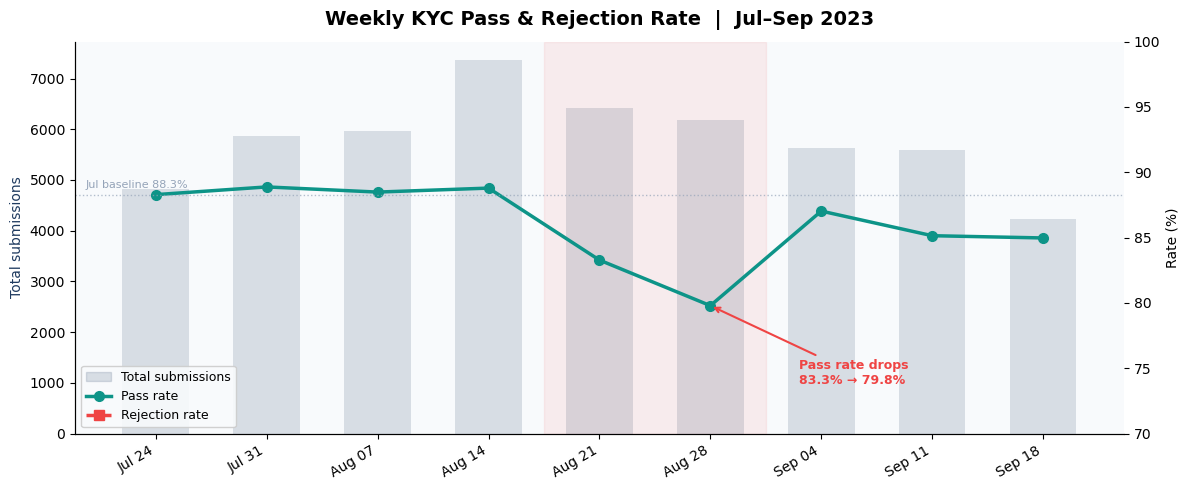

In [7]:
# --- Chart: weekly pass rate + volume ---
# I'm using a dual-axis chart: bars show volume, lines show rates.
# This makes it easy to see whether a rate change is driven by volume or not.

fig, ax_vol = plt.subplots(figsize=(12, 5))
ax_rate = ax_vol.twinx()  # second y-axis for the percentage lines

x = np.arange(len(weekly))

# Volume bars in the background (low alpha so they don't overpower the lines).
ax_vol.bar(x, weekly['total'], color=NAVY, alpha=0.15, width=0.6, label='Total submissions')

# Pass rate and rejection rate lines.
ax_rate.plot(x, weekly['pass_rate'], color=TEAL,  marker='o', lw=2.5, ms=7, label='Pass rate')
ax_rate.plot(x, weekly['rej_rate'],  color=CORAL, marker='s', lw=2.5, ms=7, label='Rejection rate', ls='--')

# Shade the two worst weeks so they jump out.
ax_rate.axvspan(3.5, 5.5, alpha=0.08, color=CORAL)

# Reference line at the July baseline so we can see how far we've drifted.
baseline = weekly['pass_rate'].iloc[0]
ax_rate.axhline(baseline, color=GREY, ls=':', lw=1, alpha=0.7)
ax_rate.annotate(
    f'Jul baseline {baseline:.1f}%',
    xy=(0.01, baseline + 0.5), xycoords=('axes fraction', 'data'),
    fontsize=8, color=GREY
)

# Arrow pointing to the worst week.
worst_idx  = weekly['pass_rate'].idxmin()
worst_rate = weekly['pass_rate'].min()
worst_x    = list(weekly.index).index(worst_idx)
ax_rate.annotate(
    f'Pass rate drops\n{weekly["pass_rate"].iloc[worst_x - 1]:.1f}% → {worst_rate:.1f}%',
    xy=(worst_x, worst_rate), xytext=(worst_x + 0.8, worst_rate - 6),
    fontsize=9, color=CORAL, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.5)
)

# Axis labels and legend.
ax_vol.set_xticks(x)
ax_vol.set_xticklabels([w.strftime('%b %d') for w in weekly.index], rotation=30, ha='right')
ax_vol.set_ylabel('Total submissions', color=NAVY)
ax_rate.set_ylabel('Rate (%)')
ax_rate.set_ylim(70, 100)

# Combine legends from both axes.
bar_patch = mpatches.Patch(color=NAVY, alpha=0.15, label='Total submissions')
rate_lines, rate_labels = ax_rate.get_legend_handles_labels()
ax_vol.legend(handles=[bar_patch] + rate_lines, loc='lower left', fontsize=9, framealpha=0.9)

ax_vol.set_title('Weekly KYC Pass & Rejection Rate  |  Jul–Sep 2023', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

> **What we see:** Pass rate was steady at ~88% through mid-August, then dropped to **79.8%** the week of Aug 28. It recovered partially but has settled around **85%** — about **3 pp below** where we started.

## 5. Join the Datasets for Check-Level Analysis

To understand *why* people are being rejected, I need the per-check columns from KYC_Details. Only ~10% of records match on `user_reference`, so I'll work with that smaller joined set for root cause analysis.

In [8]:
# Inner join — only keep rows where we have both summary outcome AND check details.
merged = summary.merge(details, on='user_reference', how='inner')

print(f'Joined dataset: {len(merged):,} rows')
print(f'That is {len(merged) / len(summary) * 100:.0f}% of all summary records')
print()
print('Outcome breakdown in joined set:')
print(merged['decision_type'].value_counts())

# Pull out just the rejected rows — this is what we'll dig into.
rejected = merged[merged['decision_type'] == 'REJECTED'].copy()
print(f'\nRejected records available for analysis: {len(rejected):,}')

Joined dataset: 5,223 rows
That is 10% of all summary records

Outcome breakdown in joined set:
PASSED      4441
REJECTED     722
WARNING       59
APPROVED       1
Name: decision_type, dtype: int64

Rejected records available for analysis: 722


## 6. Root Cause Analysis

Now let's look at what actually caused each rejection. Each check has a `_decision` column (PASSED/REJECTED/NOT_EXECUTED) and a `_decision_details` column with a specific reason code.

In [9]:
# First, a high-level view — which individual checks are failing most?
# NOT_EXECUTED means the check was skipped because an earlier one failed.

check_columns = [
    'usability_decision',
    'image_checks_decision',
    'extraction_decision',
    'data_checks_decision',
    'liveness_decision',
    'similarity_decision',
    'watchlist_screening_decision',
]

print(f'Check-level outcomes (full details dataset, n={len(details):,})')
print('=' * 70)
for col in check_columns:
    counts = details[col].value_counts()
    n_rej  = counts.get('REJECTED',     0)
    n_warn = counts.get('WARNING',       0)
    n_skip = counts.get('NOT_EXECUTED',  0)
    pct    = n_rej / len(details) * 100
    print(f'  {col:<35}  REJECTED: {n_rej:>5,} ({pct:.1f}%)  |  WARNING: {n_warn:>4,}  |  SKIPPED: {n_skip:>4,}')

Check-level outcomes (full details dataset, n=52,075)
  usability_decision                   REJECTED:   933 (1.8%)  |  WARNING:  787  |  SKIPPED:  708
  image_checks_decision                REJECTED:   945 (1.8%)  |  WARNING:    0  |  SKIPPED: 3,910
  extraction_decision                  REJECTED:     0 (0.0%)  |  WARNING:    0  |  SKIPPED: 3,910
  data_checks_decision                 REJECTED:     9 (0.0%)  |  WARNING:    0  |  SKIPPED: 4,855
  liveness_decision                    REJECTED: 1,032 (2.0%)  |  WARNING:  148  |  SKIPPED:    1
  similarity_decision                  REJECTED: 1,104 (2.1%)  |  WARNING:  408  |  SKIPPED: 2,637
  watchlist_screening_decision         REJECTED:     0 (0.0%)  |  WARNING:   69  |  SKIPPED:    1


In [10]:
# Now let's build a root-cause taxonomy from the detail codes.
# I'm mapping the raw Jumio reason codes into human-readable categories.

n_rej = len(rejected)  # denominator for percentages

# Each entry: label -> boolean mask on the rejected dataframe
root_causes = {
    'Identity Mismatch (face does not match ID)': (
        rejected['similarity_decision_details'] == 'NO_MATCH'
    ),
    'Liveness check – result undetermined': (
        rejected['liveness_decision_details'] == 'liveness_UNDETERMINED'
    ),
    'Fraud – document has been manipulated': (
        rejected['image_checks_decision_details'].str.contains('MANIPULATED', na=False)
    ),
    'Missing or incomplete document': (
        rejected['usability_decision_details'].isin([
            'MISSING_MANDATORY_DATAPOINTS', 'MISSING_PAGE', 'NOT_UPLOADED'
        ])
    ),
    'Unsupported document type': (
        rejected['usability_decision_details'] == 'UNSUPPORTED_DOCUMENT_TYPE'
    ),
    'Technical error (Jumio side or app side)': (
        rejected['usability_decision_details'] == 'TECHNICAL_ERROR'
    ),
    'Poor image quality (blur / glare / damaged)': (
        rejected['usability_decision_details'].isin([
            'BLURRED', 'GLARE', 'DAMAGED_DOCUMENT', 'PHOTOCOPY'
        ])
    ),
    'Fraud – user photographed a screen (digital copy)': (
        rejected['image_checks_decision_details'] == 'DIGITAL_COPY'
    ),
    'Liveness – face not fully visible or bad quality': (
        rejected['liveness_decision_details'].isin([
            'FACE_NOT_FULLY_VISIBLE', 'BAD_QUALITY', 'ID_USED_AS_SELFIE'
        ])
    ),
}

# Count how many rejections each cause accounts for.
cause_counts = {label: mask.sum() for label, mask in root_causes.items()}

# Sort by count descending so the biggest problems are at the top.
cause_counts = dict(sorted(cause_counts.items(), key=lambda x: x[1], reverse=True))

print(f'Root causes — {n_rej} rejected records')
print('=' * 70)
for label, count in cause_counts.items():
    pct = count / n_rej * 100
    bar = '█' * int(pct / 1.5)  # tiny ASCII bar to make it scannable
    print(f'  {count:>4} ({pct:5.1f}%)  {bar}  {label}')

Root causes — 722 rejected records
   131 ( 18.1%)  ████████████  Identity Mismatch (face does not match ID)
    97 ( 13.4%)  ████████  Liveness check – result undetermined
    72 ( 10.0%)  ██████  Fraud – document has been manipulated
    69 (  9.6%)  ██████  Missing or incomplete document
    55 (  7.6%)  █████  Unsupported document type
    43 (  6.0%)  ███  Technical error (Jumio side or app side)
    42 (  5.8%)  ███  Poor image quality (blur / glare / damaged)
    22 (  3.0%)  ██  Fraud – user photographed a screen (digital copy)
    10 (  1.4%)    Liveness – face not fully visible or bad quality


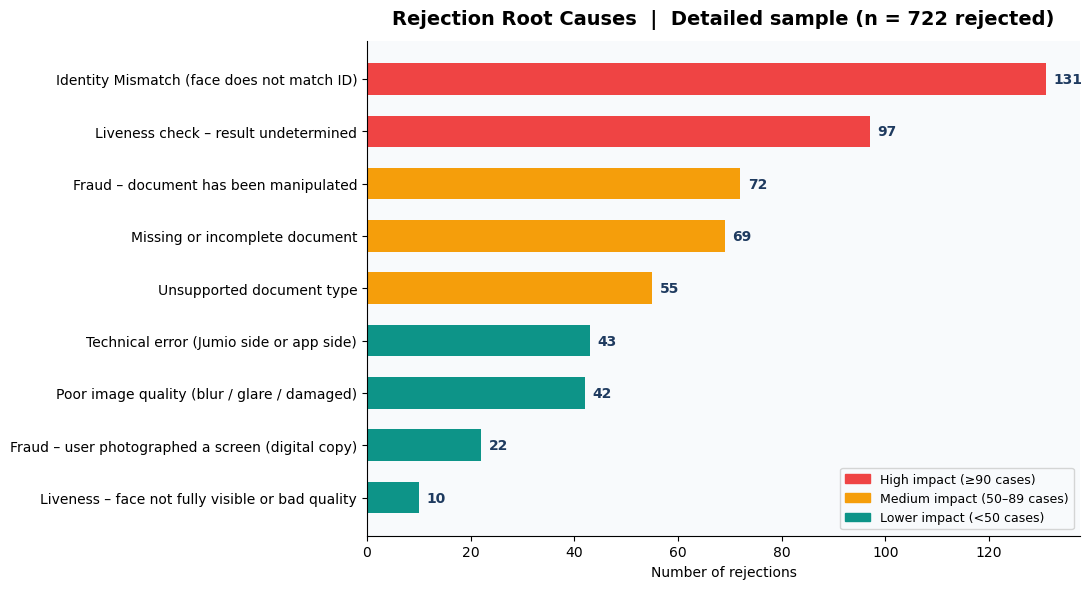

In [11]:
# --- Chart: root causes ranked ---
# Horizontal bar chart — easiest to read for ranked lists with long labels.

labels = list(cause_counts.keys())
values = list(cause_counts.values())

# Colour-code by impact level so it's obvious which ones matter most.
bar_colours = [CORAL if v >= 90 else AMBER if v >= 50 else TEAL for v in values]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(range(len(labels)), values, color=bar_colours, height=0.6)

# Put the count at the end of each bar.
for bar, v in zip(bars, values):
    ax.text(
        bar.get_width() + 1.5,
        bar.get_y() + bar.get_height() / 2,
        str(v), va='center', fontsize=10, fontweight='bold', color=NAVY
    )

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()  # biggest bar at the top
ax.set_xlabel('Number of rejections')
ax.set_title(
    f'Rejection Root Causes  |  Detailed sample (n = {n_rej} rejected)',
    fontsize=14, fontweight='bold', pad=12
)

# Legend explains the colour thresholds.
legend_patches = [
    mpatches.Patch(color=CORAL, label='High impact (≥90 cases)'),
    mpatches.Patch(color=AMBER, label='Medium impact (50–89 cases)'),
    mpatches.Patch(color=TEAL,  label='Lower impact (<50 cases)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Country Breakdown: Mexico vs Argentina

We operate in two markets. Let's see if the pass rate problem is worse in one country.

In [12]:
# Helper function to get KYC stats for a given country code.
# Returns a dict so I can easily build a summary table.
def get_country_stats(df, country_code):
    subset = df[df['data_issuing_country'] == country_code]
    n       = len(subset)
    passed  = (subset['decision_label'] == 'PASSED').sum()
    rejected = (subset['decision_label'] == 'REJECTED').sum()
    manipulated = subset['image_checks_decision_details'].str.contains('MANIPULATED', na=False).sum()
    digital_copy = (subset['image_checks_decision_details'] == 'DIGITAL_COPY').sum()
    unsupported  = (subset['usability_decision_details'] == 'UNSUPPORTED_DOCUMENT_TYPE').sum()
    return {
        'Total KYC'           : n,
        'Passed'              : passed,
        'Rejected'            : rejected,
        'Pass Rate %'         : round(passed   / n * 100, 1),
        'Rejection Rate %'    : round(rejected / n * 100, 1),
        'Manipulated Docs'    : manipulated,
        'Digital Copies'      : digital_copy,
        'Unsupported Doc Type': unsupported,
    }

mex_stats = get_country_stats(details, 'MEX')
arg_stats = get_country_stats(details, 'ARG')

# Print side by side for easy comparison.
print(f'{"Metric":<25} {"Mexico (MEX)":>15} {"Argentina (ARG)":>16}')
print('-' * 60)
for key in mex_stats:
    mex_val = mex_stats[key]
    arg_val = arg_stats[key]
    # Format numbers with commas, add % symbol where needed.
    fmt = '{:,.1f}%' if '%' in key else '{:,}'
    print(f'  {key:<23} {fmt.format(mex_val):>15} {fmt.format(arg_val):>16}')

Metric                       Mexico (MEX)  Argentina (ARG)
------------------------------------------------------------
  Total KYC                        29,706           22,369
  Passed                           24,220           20,595
  Rejected                          5,157            1,616
  Pass Rate %                       81.5%            92.1%
  Rejection Rate %                  17.4%             7.2%
  Manipulated Docs                    186              509
  Digital Copies                      180               45
  Unsupported Doc Type                509                0


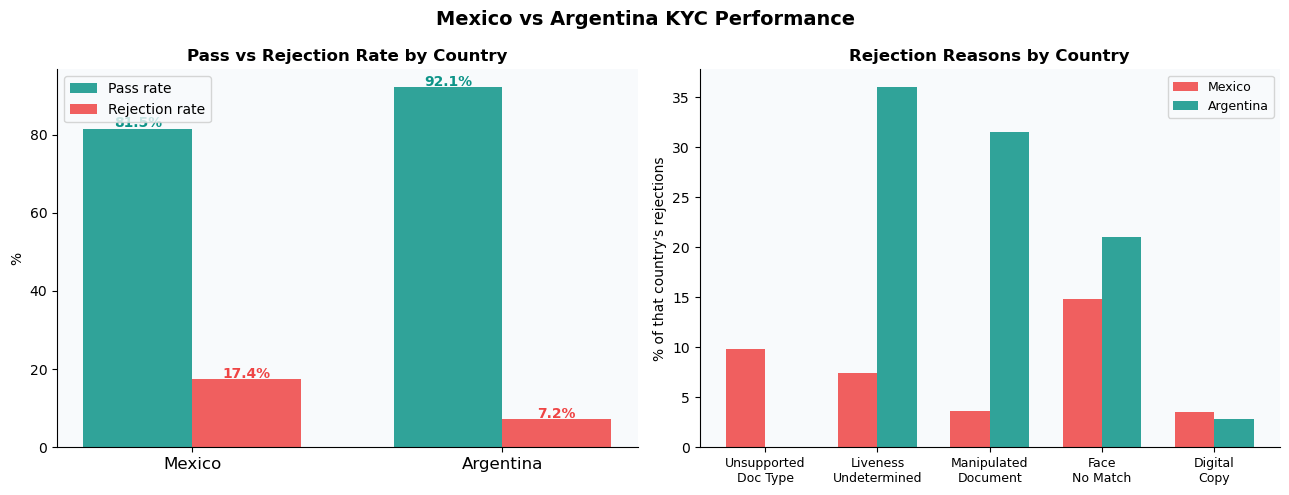

In [13]:
# --- Chart: pass/rejection rate + top rejection reasons by country ---

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 5))

countries    = ['Mexico', 'Argentina']
pass_rates   = [mex_stats['Pass Rate %'],      arg_stats['Pass Rate %']]
reject_rates = [mex_stats['Rejection Rate %'], arg_stats['Rejection Rate %']]
colours      = [CORAL, TEAL]

# Left panel — pass vs rejection rate per country.
x = np.arange(2)
w = 0.35
ax_left.bar(x - w/2, pass_rates,   w, color=TEAL,  alpha=0.85, label='Pass rate')
ax_left.bar(x + w/2, reject_rates, w, color=CORAL, alpha=0.85, label='Rejection rate')
ax_left.set_xticks(x)
ax_left.set_xticklabels(countries, fontsize=12)
ax_left.set_ylabel('%')
ax_left.legend(fontsize=10)
ax_left.set_title('Pass vs Rejection Rate by Country', fontsize=12, fontweight='bold')
ax_left.set_facecolor(BG)

# Add value labels on the bars.
for i, (pr, rr) in enumerate(zip(pass_rates, reject_rates)):
    ax_left.text(i - w/2, pr + 0.4, f'{pr:.1f}%', ha='center', fontsize=10, fontweight='bold', color=TEAL)
    ax_left.text(i + w/2, rr + 0.4, f'{rr:.1f}%', ha='center', fontsize=10, fontweight='bold', color=CORAL)

# Right panel — what's causing rejections in each country?
# I'm using the full details dataset here (not just the joined subset)
# because we have country info for all 52k records.
def get_rejection_reasons(df, country_code):
    rej = df[(df['data_issuing_country'] == country_code) & (df['decision_label'] == 'REJECTED')]
    n = len(rej)
    if n == 0:
        return {}
    return {
        'Unsupported\nDoc Type' : (rej['usability_decision_details'] == 'UNSUPPORTED_DOCUMENT_TYPE').sum() / n * 100,
        'Liveness\nUndetermined': (rej['liveness_decision_details'] == 'liveness_UNDETERMINED').sum()      / n * 100,
        'Manipulated\nDocument' : rej['image_checks_decision_details'].str.contains('MANIPULATED', na=False).sum() / n * 100,
        'Face\nNo Match'        : (rej['similarity_decision_details'] == 'NO_MATCH').sum()                 / n * 100,
        'Digital\nCopy'         : (rej['image_checks_decision_details'] == 'DIGITAL_COPY').sum()           / n * 100,
    }

mex_reasons = get_rejection_reasons(details, 'MEX')
arg_reasons = get_rejection_reasons(details, 'ARG')

reason_labels = list(mex_reasons.keys())
x2 = np.arange(len(reason_labels))
ax_right.bar(x2 - w/2, list(mex_reasons.values()), w, color=CORAL, alpha=0.85, label='Mexico')
ax_right.bar(x2 + w/2, list(arg_reasons.values()), w, color=TEAL,  alpha=0.85, label='Argentina')
ax_right.set_xticks(x2)
ax_right.set_xticklabels(reason_labels, fontsize=9)
ax_right.set_ylabel('% of that country\'s rejections')
ax_right.legend(fontsize=9)
ax_right.set_title('Rejection Reasons by Country', fontsize=12, fontweight='bold')
ax_right.set_facecolor(BG)

fig.suptitle('Mexico vs Argentina KYC Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Mexico's rejection rate (17.4%) is more than double Argentina's (7.2%).** The biggest Mexico-specific issue is unsupported document types — likely certain Mexican voter ID formats that Jumio doesn't recognise. Argentina has far more document manipulation fraud despite fewer overall rejections.

## 8. Performance by Document Type

In [14]:
# Calculate pass and rejection rates for each document type.
doc_outcomes = (
    details
    .groupby('data_type')['decision_label']
    .value_counts()
    .unstack(fill_value=0)
)

doc_outcomes['total']    = doc_outcomes.sum(axis=1)
doc_outcomes['pass_pct'] = doc_outcomes.get('PASSED',   0) / doc_outcomes['total'] * 100
doc_outcomes['rej_pct']  = doc_outcomes.get('REJECTED', 0) / doc_outcomes['total'] * 100

# Sort so the worst-performing type is shown first.
doc_outcomes = doc_outcomes.sort_values('pass_pct')

print('Document type performance:')
print(doc_outcomes[['total', 'pass_pct', 'rej_pct']].round(1))

Document type performance:
decision_label   total  pass_pct  rej_pct
data_type                                
DRIVING_LICENSE    972      89.5      9.4
ID_CARD          44637      92.6      6.3
VISA                24      95.8      4.2
PASSPORT          2660      96.4      3.2


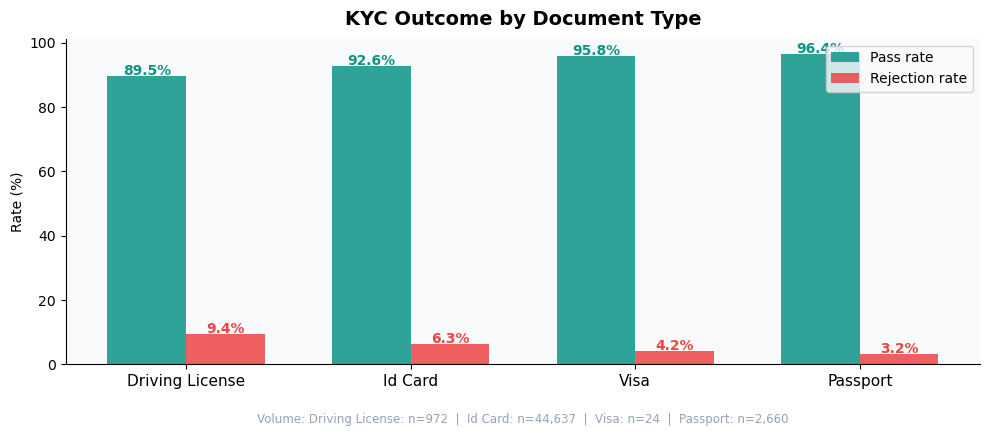

In [15]:
# --- Chart: pass and rejection rate side by side per doc type ---

doc_types = doc_outcomes.index
x = np.arange(len(doc_types))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 4.5))

pass_bars = ax.bar(x - w/2, doc_outcomes['pass_pct'], w, color=TEAL,  alpha=0.85, label='Pass rate')
rej_bars  = ax.bar(x + w/2, doc_outcomes['rej_pct'],  w, color=CORAL, alpha=0.85, label='Rejection rate')

# Label each bar with its value.
for bar in pass_bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, color=TEAL, fontweight='bold')
for bar in rej_bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, color=CORAL, fontweight='bold')

# Clean up the x-axis labels (replace underscores and title-case).
ax.set_xticks(x)
ax.set_xticklabels([d.replace('_', ' ').title() for d in doc_types], fontsize=11)
ax.set_ylabel('Rate (%)')
ax.legend(fontsize=10)
ax.set_title('KYC Outcome by Document Type', fontsize=14, fontweight='bold', pad=10)
ax.set_facecolor(BG)

# Add volume info below the chart so we can judge the scale of each category.
vol_labels = '  |  '.join(
    [f"{d.replace('_', ' ').title()}: n={int(doc_outcomes.loc[d, 'total']):,}" for d in doc_types]
)
ax.text(0.5, -0.18, f'Volume: {vol_labels}', ha='center',
        transform=ax.transAxes, fontsize=8.5, color=GREY)

plt.tight_layout()
plt.show()

> **ID Cards make up 85.7% of all KYC attempts**, so even a small improvement in the ID Card rejection rate would meaningfully move the overall number. Driving licences have the worst rejection rate (9.4%) but low volume.

## 9. Fraud & Abuse Signals

Let's look specifically at the cases where someone appears to have tried to cheat the system.

In [16]:
# Pull out the three main fraud patterns.
manipulated  = details[details['image_checks_decision_details'].str.contains('MANIPULATED', na=False)]
digital_copy = details[details['image_checks_decision_details'] == 'DIGITAL_COPY']
id_as_selfie = details[details['liveness_decision_details']     == 'ID_USED_AS_SELFIE']

total_n = len(details)

print('Fraud / abuse signal summary')
print('=' * 55)

print(f'\n1. Manipulated documents: {len(manipulated):,} cases ({len(manipulated)/total_n*100:.2f}% of all KYC)')
print('   Type breakdown:')
print(manipulated['image_checks_decision_details'].value_counts().to_string())
print('   Country breakdown:')
print(manipulated['data_issuing_country'].value_counts().to_string())

print(f'\n2. Digital copies (screen photo of ID): {len(digital_copy):,} cases ({len(digital_copy)/total_n*100:.2f}%)')
print('   Country breakdown:')
print(digital_copy['data_issuing_country'].value_counts().to_string())

print(f'\n3. ID photo submitted as selfie: {len(id_as_selfie):,} cases ({len(id_as_selfie)/total_n*100:.2f}%)')
print('   Country breakdown:')
print(id_as_selfie['data_issuing_country'].value_counts().to_string())

total_fraud = len(manipulated) + len(digital_copy) + len(id_as_selfie)
print(f'\nTotal fraud-related cases: {total_fraud:,} ({total_fraud/total_n*100:.2f}% of all KYC)')

Fraud / abuse signal summary

1. Manipulated documents: 695 cases (1.33% of all KYC)
   Type breakdown:
MANIPULATED_DOCUMENT                    537
MANIPULATED_DOCUMENT_PHOTO               61
MANIPULATED_DOCUMENT_DOB                 57
MANIPULATED_DOCUMENT_DOCUMENT_NUMBER     19
MANIPULATED_DOCUMENT_SECURITY_CHECKS     13
MANIPULATED_DOCUMENT_NAME                 6
MANIPULATED_DOCUMENT_EXPIRY               2
   Country breakdown:
ARG    509
MEX    186

2. Digital copies (screen photo of ID): 225 cases (0.43%)
   Country breakdown:
MEX    180
ARG     45

3. ID photo submitted as selfie: 14 cases (0.03%)
   Country breakdown:
MEX    9
ARG    5

Total fraud-related cases: 934 (1.79% of all KYC)


## 10. Liveness & Identity Check Deep Dive

These two checks together account for the largest share of rejections. Let's understand the specific failure sub-types.

In [17]:
# --- Liveness check ---
# REJECTED means Jumio couldn't confirm the person is real.
# 'liveness_UNDETERMINED' is the most common sub-type — it doesn't mean fake,
# just that the quality wasn't good enough to make a decision.

print('Liveness check outcomes:')
print(details['liveness_decision'].value_counts())

liveness_fails = details[details['liveness_decision'] == 'REJECTED']
print(f'\nRejection sub-reasons (n={len(liveness_fails):,}):')
print(liveness_fails['liveness_decision_details'].value_counts())

Liveness check outcomes:
PASSED          50894
REJECTED         1032
WARNING           148
NOT_EXECUTED        1
Name: liveness_decision, dtype: int64

Rejection sub-reasons (n=1,032):
liveness_UNDETERMINED     965
FACE_NOT_FULLY_VISIBLE     53
ID_USED_AS_SELFIE          14
Name: liveness_decision_details, dtype: int64


In [18]:
# --- Similarity / identity check ---
# This compares the selfie to the photo on the ID.
# A NO_MATCH rejection means Jumio is confident the faces are different.

print('Identity (similarity) check outcomes:')
print(details['similarity_decision'].value_counts())

sim_fails = details[details['similarity_decision'] == 'REJECTED']
print(f'\nRejection sub-reasons (n={len(sim_fails):,}):')
print(sim_fails['similarity_decision_details'].value_counts())
print(f'\nAll {len(sim_fails):,} similarity rejections are confirmed NO_MATCH — '
      f'not borderline cases.')

Identity (similarity) check outcomes:
PASSED          47926
NOT_EXECUTED     2637
REJECTED         1104
WARNING           408
Name: similarity_decision, dtype: int64

Rejection sub-reasons (n=1,104):
NO_MATCH    1104
Name: similarity_decision_details, dtype: int64

All 1,104 similarity rejections are confirmed NO_MATCH — not borderline cases.


## 11. Technical Errors & Unsupported Documents

In [19]:
# Technical errors — these are cases where the system itself failed,
# rather than the user doing something wrong. Worth monitoring separately.
tech_errors = details[details['usability_decision_details'] == 'TECHNICAL_ERROR']

print(f'Technical errors: {len(tech_errors):,} ({len(tech_errors)/len(details)*100:.2f}% of all KYC)')
print('By country:')
print(tech_errors['data_issuing_country'].value_counts())
print('Final outcome for these records:')
print(tech_errors['decision_label'].value_counts())

print()

# Unsupported document types — Jumio simply can't process this ID format.
# 100% of these come from Mexico, likely older voter ID formats.
unsupported = details[details['usability_decision_details'] == 'UNSUPPORTED_DOCUMENT_TYPE']

print(f'Unsupported document type: {len(unsupported):,} ({len(unsupported)/len(details)*100:.2f}% of all KYC)')
print('By country:')
print(unsupported['data_issuing_country'].value_counts())

Technical errors: 407 (0.78% of all KYC)
By country:
MEX    262
ARG    145
Name: data_issuing_country, dtype: int64
Final outcome for these records:
REJECTED    407
Name: decision_label, dtype: int64

Unsupported document type: 509 (0.98% of all KYC)
By country:
MEX    509
Name: data_issuing_country, dtype: int64


## 12. Summary of Findings

All the numbers in one place, computed directly from the data.

In [20]:
# ── Helper: apply a consistent table style ──────────────────────────────
# Reusable function so all four tables below look the same without
# repeating the styling dict every time.
def style_table(df, bar_col=None, highlight_max_cols=None, highlight_min_cols=None, fmt=None):
    """
    Apply a clean, consistent style to a pandas DataFrame for display in Jupyter.

    Parameters
    ----------
    df                : DataFrame to style
    bar_col           : column name to add an in-cell bar chart (optional)
    highlight_max_cols: list of column names to highlight the highest value red
    highlight_min_cols: list of column names to highlight the lowest value green
    fmt               : dict of {column: format_string} passed to .format()
    """
    # Base styles that apply to every table.
    table_styles = [
        {'selector': 'thead th',
         'props': [('background-color', '#1E3A5F'), ('color', 'white'),
                   ('font-size', '13px'), ('padding', '8px 14px')]},
        {'selector': 'tbody td',
         'props': [('padding', '7px 14px'), ('font-size', '13px')]},
        {'selector': 'tbody tr:nth-child(even)',
         'props': [('background-color', '#F8FAFC')]},
    ]

    styled = df.style.hide(axis='index').set_table_styles(table_styles)

    if bar_col:
        styled = styled.bar(subset=[bar_col], color='#CCFBF1', vmin=0)

    if highlight_max_cols:
        styled = styled.highlight_max(subset=highlight_max_cols, color='#FEE2E2')

    if highlight_min_cols:
        styled = styled.highlight_min(subset=highlight_min_cols, color='#CCFBF1')

    if fmt:
        styled = styled.format(fmt)

    return styled


# ── Helper: section heading HTML ─────────────────────────────────────────
def section_heading(number, title, subtitle=''):
    """Render a styled heading above each summary table."""
    sub = f'<span style="font-weight:normal;font-size:13px;color:#64748B"> — {subtitle}</span>' if subtitle else ''
    display(HTML(f'<h3 style="color:#1E3A5F;margin-top:24px;margin-bottom:6px">{number} {title}{sub}</h3>'))

In [21]:
# ── ① Headline pass-rate metrics ────────────────────────────────────────

# Recalculate from scratch so this section is self-contained
# and doesn't depend on variables set earlier in the notebook.
n_total   = len(summary)
n_passed  = (summary['decision_type'] == 'PASSED').sum()
n_rejected_all = (summary['decision_type'] == 'REJECTED').sum()

# Weekly pass rates to find the baseline, lowest, and end values.
summary['week'] = summary['date_'].dt.to_period('W')
wk = summary.groupby(['week', 'decision_type']).size().unstack(fill_value=0)
wk['total']     = wk.sum(axis=1)
wk['pass_rate'] = wk.get('PASSED', 0) / wk['total'] * 100

baseline = wk['pass_rate'].iloc[0]
lowest   = wk['pass_rate'].min()
end_rate = wk['pass_rate'].iloc[-1]
overall  = n_passed / n_total * 100

headline_df = pd.DataFrame({
    'Metric': [
        'Overall pass rate (Jul–Sep)',
        'July baseline rate (first week)',
        'Lowest point (week of Aug 28)',
        'September end rate',
        'Total rejections (all 9 weeks)',
    ],
    'Value': [
        f'{overall:.1f}%',
        f'{baseline:.1f}%',
        f'{lowest:.1f}%',
        f'{end_rate:.1f}%',
        f'{n_rejected_all:,}',
    ],
    'vs Baseline': [
        '—',
        '—',
        f'−{baseline - lowest:.1f} pp',
        f'−{baseline - end_rate:.1f} pp',
        '—',
    ],
})

section_heading('①', 'Headline Metrics')

# Highlight negative deltas in red so they stand out.
styled = style_table(headline_df)
styled = styled.applymap(
    lambda v: 'color:#EF4444;font-weight:bold' if '−' in str(v) else '',
    subset=['vs Baseline']
)
display(styled)

Metric,Value,vs Baseline
Overall pass rate (Jul–Sep),86.1%,—
July baseline rate (first week),88.3%,—
Lowest point (week of Aug 28),79.8%,−8.5 pp
September end rate,85.0%,−3.3 pp
Total rejections (all 9 weeks),"6,772",—


In [22]:
# ── ② Root cause table ──────────────────────────────────────────────────

n_rej_detail = len(rejected)  # denominator = rejections in the joined sample

# Same root cause mapping as Section 6 — repeated here so the summary
# cell is standalone and can be run on its own.
root_cause_map = {
    'Identity Mismatch (Face ≠ Document)':        (rejected['similarity_decision_details'] == 'NO_MATCH').sum(),
    'Liveness – Undetermined':                    (rejected['liveness_decision_details'] == 'liveness_UNDETERMINED').sum(),
    'Fraud – Manipulated Document':               rejected['image_checks_decision_details'].str.contains('MANIPULATED', na=False).sum(),
    'Missing Data / Incomplete Document':         rejected['usability_decision_details'].isin(['MISSING_MANDATORY_DATAPOINTS', 'MISSING_PAGE', 'NOT_UPLOADED']).sum(),
    'Unsupported Document Type':                  (rejected['usability_decision_details'] == 'UNSUPPORTED_DOCUMENT_TYPE').sum(),
    'Technical Error':                            (rejected['usability_decision_details'] == 'TECHNICAL_ERROR').sum(),
    'Poor Image Quality (Blur / Glare / Damaged)':(rejected['usability_decision_details'].isin(['BLURRED', 'GLARE', 'DAMAGED_DOCUMENT', 'PHOTOCOPY'])).sum(),
    'Fraud – Digital Copy of ID':                 (rejected['image_checks_decision_details'] == 'DIGITAL_COPY').sum(),
    'Liveness – Face Not Visible / Bad Quality':  rejected['liveness_decision_details'].isin(['FACE_NOT_FULLY_VISIBLE', 'BAD_QUALITY', 'ID_USED_AS_SELFIE']).sum(),
}

# Build the dataframe, sorted biggest to smallest.
rc_rows = [
    {
        'Rank'            : i + 1,
        'Root Cause'      : label,
        'Cases'           : count,
        '% of Rejections' : round(count / n_rej_detail * 100, 1),
        'Category'        : (
            '🔴 Identity / Liveness' if any(k in label for k in ['Mismatch', 'Liveness'])
            else '🟠 Fraud'           if 'Fraud'       in label
            else '🟡 Document / UX'  if any(k in label for k in ['Unsupported', 'Missing', 'Quality'])
            else '⚪ Other'
        ),
    }
    for i, (label, count) in enumerate(
        sorted(root_cause_map.items(), key=lambda x: x[1], reverse=True)
    )
]
rc_df = pd.DataFrame(rc_rows)

section_heading('②', 'Rejection Root Causes', f'joined sample · n = {n_rej_detail} rejected')

# Category column gets colour-coded; in-cell bars on Cases and %.
def colour_category(val):
    if '🔴' in str(val): return 'color:#EF4444;font-weight:bold'
    if '🟠' in str(val): return 'color:#F59E0B;font-weight:bold'
    if '🟡' in str(val): return 'color:#D97706;font-weight:bold'
    return ''

styled_rc = (
    style_table(rc_df, fmt={'Cases': '{:,}', '% of Rejections': '{:.1f}%'})
    .bar(subset=['Cases'],            color='#CCFBF1', vmin=0)
    .bar(subset=['% of Rejections'],  color='#FEE2E2', vmin=0)
    .applymap(colour_category, subset=['Category'])
)
display(styled_rc)

Rank,Root Cause,Cases,% of Rejections,Category
1,Identity Mismatch (Face ≠ Document),131,18.1%,🔴 Identity / Liveness
2,Liveness – Undetermined,97,13.4%,🔴 Identity / Liveness
3,Fraud – Manipulated Document,72,10.0%,🟠 Fraud
4,Missing Data / Incomplete Document,69,9.6%,🟡 Document / UX
5,Unsupported Document Type,55,7.6%,🟡 Document / UX
6,Technical Error,43,6.0%,⚪ Other
7,Poor Image Quality (Blur / Glare / Damaged),42,5.8%,🟡 Document / UX
8,Fraud – Digital Copy of ID,22,3.0%,🟠 Fraud
9,Liveness – Face Not Visible / Bad Quality,10,1.4%,🔴 Identity / Liveness


In [23]:
# ── ③ Country breakdown ──────────────────────────────────────────────────

# Build one row per country using the helper from Section 7.
country_df = pd.DataFrame([
    {'Country': 'Mexico',    **get_country_stats(details, 'MEX')},
    {'Country': 'Argentina', **get_country_stats(details, 'ARG')},
])

section_heading('③', 'Country Breakdown')

display(
    style_table(
        country_df,
        highlight_max_cols=['Rejection Rate %', 'Manipulated Docs', 'Digital Copies', 'Unsupported Doc Type'],
        highlight_min_cols=['Rejection Rate %'],
        fmt={
            'Total KYC'           : '{:,}',
            'Passed'              : '{:,}',
            'Rejected'            : '{:,}',
            'Pass Rate %'         : '{:.1f}%',
            'Rejection Rate %'    : '{:.1f}%',
            'Manipulated Docs'    : '{:,}',
            'Digital Copies'      : '{:,}',
            'Unsupported Doc Type': '{:,}',
        }
    )
)

Country,Total KYC,Passed,Rejected,Pass Rate %,Rejection Rate %,Manipulated Docs,Digital Copies,Unsupported Doc Type
Mexico,"29,706","24,220","5,157",81.5%,17.4%,186,180,509
Argentina,"22,369","20,595","1,616",92.1%,7.2%,509,45,0


In [25]:
# ── ④ Fraud signals breakdown ────────────────────────────────────────────

# Build a table that shows total + per-country split for each fraud type.
# I'm defining a small helper to avoid repeating the filter logic for each row.
def fraud_row(signal_name, mask_total, mask_mex, mask_arg):
    """Return a dict representing one row in the fraud summary table."""
    return {
        'Fraud Signal': signal_name,
        'Total'       : mask_total.sum(),
        'Mexico'      : mask_mex.sum(),
        'Argentina'   : mask_arg.sum(),
    }

# Shorthand filters used repeatedly below.
is_mex = details['data_issuing_country'] == 'MEX'
is_arg = details['data_issuing_country'] == 'ARG'
img    = details['image_checks_decision_details']
live   = details['liveness_decision_details']

fraud_rows = [
    fraud_row(
        'Manipulated document (any field)',
        img.str.contains('MANIPULATED', na=False),
        (is_mex & img.str.contains('MANIPULATED', na=False)),
        (is_arg & img.str.contains('MANIPULATED', na=False)),
    ),
    fraud_row(
        '   General manipulation',
        img == 'MANIPULATED_DOCUMENT',
        (is_mex & (img == 'MANIPULATED_DOCUMENT')),
        (is_arg & (img == 'MANIPULATED_DOCUMENT')),
    ),
    fraud_row(
        '   Photo manipulation',
        img == 'MANIPULATED_DOCUMENT_PHOTO',
        (is_mex & (img == 'MANIPULATED_DOCUMENT_PHOTO')),
        (is_arg & (img == 'MANIPULATED_DOCUMENT_PHOTO')),
    ),
    fraud_row(
        '   Date-of-birth manipulation',
        img == 'MANIPULATED_DOCUMENT_DOB',
        (is_mex & (img == 'MANIPULATED_DOCUMENT_DOB')),
        (is_arg & (img == 'MANIPULATED_DOCUMENT_DOB')),
    ),
    fraud_row(
        'Digital copy of ID (photographed from a screen)',
        img == 'DIGITAL_COPY',
        (is_mex & (img == 'DIGITAL_COPY')),
        (is_arg & (img == 'DIGITAL_COPY')),
    ),
    fraud_row(
        'ID photo submitted as selfie',
        live == 'ID_USED_AS_SELFIE',
        (is_mex & (live == 'ID_USED_AS_SELFIE')),
        (is_arg & (live == 'ID_USED_AS_SELFIE')),
    ),
]

fraud_df = pd.DataFrame(fraud_rows)

section_heading('④', 'Fraud Signals')

display(
    style_table(
        fraud_df,
        bar_col='Total',
        fmt={'Total': '{:,}', 'Mexico': '{:,}', 'Argentina': '{:,}'}
    )
)

Fraud Signal,Total,Mexico,Argentina
Manipulated document (any field),695,186,509
General manipulation,537,123,414
Photo manipulation,61,28,33
Date-of-birth manipulation,57,22,35
Digital copy of ID (photographed from a screen),225,180,45
ID photo submitted as selfie,14,9,5
